#AG3 - Actividad Guiada 3
Nombre: Julián Samblás Caballero <br>
Link:   https://colab.research.google.com/drive/1_D9TbN4_3OiHkTjuKylyZCuXtupmzVpS#scrollTo=qP-Y3Gkfc4vn <br>
Github: https://github.com/Juliansc87/Algoritmos-de-Optimizacion
<br>

#Carga de librerias

In [3]:
!pip install requests    #Hacer llamadas http a paginas de la red
!pip install -q tsplib95 --no-deps    #Modulo para las instancias del problema del TSP
!pip install -q Deprecated

#Carga de los datos del problema

In [3]:
import urllib.request #Hacer llamadas http a paginas de la red
import tsplib95       #Modulo para las instancias del problema del TSP
import math           #Modulo de funciones matematicas. Se usa para exp
import random         #Para generar valores aleatorios


#http://elib.zib.de/pub/mp-testdata/tsp/tsplib/
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/

#Descargamos el fichero de datos(Matriz de distancias)
#file = "swiss42.tsp"
#urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/swiss42.tsp.gz", file + '.gz')
#!gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#URL alternativa
file = "swiss42.tsp"
urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file)

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)

('swiss42.tsp', <http.client.HTTPMessage at 0x7c3657553b10>)

In [4]:
#Carga de datos y generación de objeto problem
###############################################################################
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())

#Aristas
Aristas = list(problem.get_edges())



In [ ]:
Aristas

In [5]:
#Comprobar el nombre del problema
print(problem.name)

#Comprobar el número de Nodos
print(len(Nodos))

#Comprobar los 10 primeros Nodos
print(Nodos[:10])

#Comprobar las 10 primeras Aristas
print(Aristas[:10])

swiss42
42
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9)]



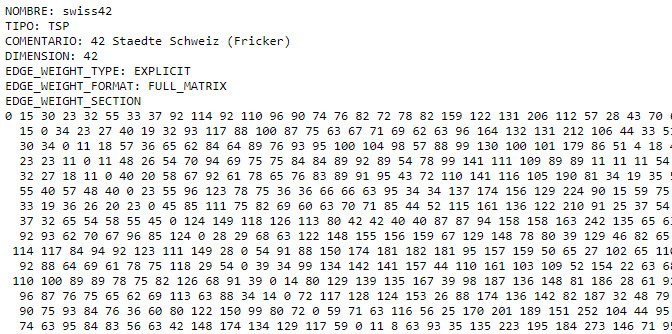

In [6]:
#Probamos algunas funciones del objeto problem

#Distancia entre nodos
problem.get_weight(0, 1)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html

#dir(problem)

15

In [7]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo solucion TSP")
    plt.show()

#Funcionas basicas


In [8]:

#Funcionas basicas
###############################################################################

#Se genera una solucion aleatoria con comienzo en en el nodo 0
def crear_solucion(Nodos):
  solucion = [Nodos[0]]
  for n in Nodos[1:]:
    solucion = solucion + [random.choice(list(set(Nodos) - set({Nodos[0]}) - set(solucion)))]
  return solucion

#Devuelve la distancia entre dos nodos
def distancia(a,b, problem):
  return problem.get_weight(a,b)

#Devuelve la distancia total de una trayectoria/solucion
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problem)
  return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problem)

sol_temporal = crear_solucion(Nodos)

distancia_total(sol_temporal, problem), sol_temporal

(4407,
 [0,
  23,
  22,
  27,
  30,
  31,
  34,
  38,
  25,
  8,
  15,
  2,
  39,
  32,
  13,
  26,
  10,
  21,
  7,
  17,
  40,
  18,
  4,
  29,
  9,
  24,
  6,
  14,
  12,
  41,
  11,
  20,
  16,
  1,
  36,
  19,
  3,
  5,
  33,
  35,
  37,
  28])

#BUSQUEDA ALEATORIA

Mejor solución: [0, 14, 11, 40, 12, 37, 7, 33, 29, 23, 24, 39, 30, 32, 20, 19, 17, 34, 41, 26, 5, 28, 2, 38, 18, 10, 25, 8, 4, 13, 3, 22, 6, 16, 15, 21, 9, 1, 27, 36, 35, 31]
Distancia     : 3744


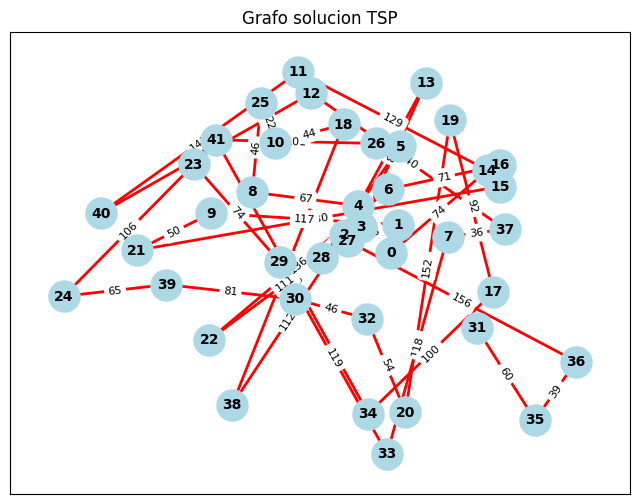

In [9]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################

def busqueda_aleatoria(problem, N):
  #N es el numero de iteraciones
  Nodos = list(problem.get_nodes())

  mejor_solucion = []
  #mejor_distancia = 10e100                         #Inicializamos con un valor alto
  mejor_distancia = float('inf')                    #Inicializamos con un valor alto

  for i in range(N):                                #Criterio de parada: repetir N veces pero podemos incluir otros
    solucion = crear_solucion(Nodos)                #Genera una solucion aleatoria
    distancia = distancia_total(solucion, problem)  #Calcula el valor objetivo(distancia total)

    if distancia < mejor_distancia:                 #Compara con la mejor obtenida hasta ahora
      mejor_solucion = solucion
      mejor_distancia = distancia


  print("Mejor solución:" , mejor_solucion)
  print("Distancia     :" , mejor_distancia)
  return mejor_solucion


#Busqueda aleatoria con 10000 iteraciones
solucion = busqueda_aleatoria(problem, 10000)

plot_tsp_solution(problem.edge_weights, solucion)

#BUSQUEDA LOCAL

In [10]:
###############################################################################
# BUSQUEDA LOCAL
###############################################################################
def genera_vecina(solucion):
  #Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones
  #Se puede modificar para aplicar otros generadores distintos que 2-opt
  #print(solucion)
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1,len(solucion)-1):          #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for j in range(i+1, len(solucion)):

      #Se genera una nueva solución intercambiando los dos nodos i,j:
      #  (usamos el operador + que para listas en python las concatena) : ej.: [1,2] + [3] = [1,2,3]
      vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

      #Se evalua la nueva solución ...
      distancia_vecina = distancia_total(vecina, problem)

      #... para guardarla si mejora las anteriores
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


#solucion = [1, 47, 13, 41, 40, 19, 42, 44, 37, 5, 22, 28, 3, 2, 29, 21, 50, 34, 30, 9, 16, 11, 38, 49, 10, 39, 33, 45, 15, 24, 43, 26, 31, 36, 35, 20, 8, 7, 23, 48, 27, 12, 17, 4, 18, 25, 14, 6, 51, 46, 32]
print("Distancia Solucion Incial:" , distancia_total(solucion, problem))


nueva_solucion = genera_vecina(solucion)
print("Distancia Mejor Solucion Local:", distancia_total(nueva_solucion, problem))


Distancia Solucion Incial: 3744
Distancia Mejor Solucion Local: 3532


En la iteracion  41 , la mejor solución encontrada es: [0, 32, 34, 33, 20, 35, 36, 31, 23, 41, 25, 11, 12, 5, 13, 19, 7, 17, 37, 15, 16, 14, 6, 1, 3, 2, 8, 10, 18, 26, 4, 27, 28, 30, 38, 22, 24, 40, 21, 39, 9, 29]
Distancia     : 1747


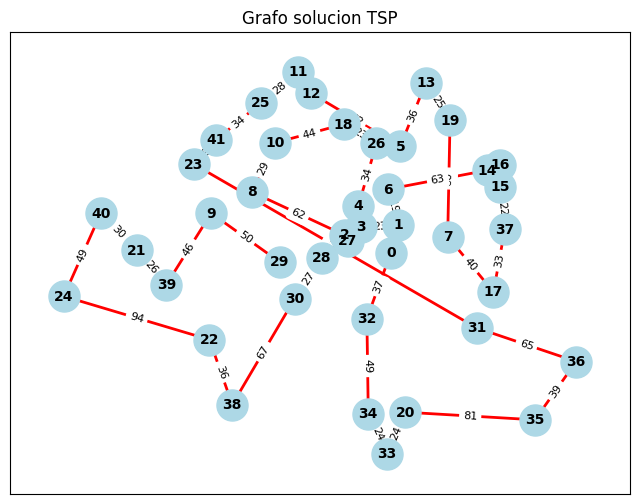

In [11]:
#Busqueda Local:
#  - Sobre el operador de vecindad 2-opt(funcion genera_vecina)
#  - Sin criterio de parada, se para cuando no es posible mejorar.
def busqueda_local(problem):
  mejor_solucion = []

  #Generar una solucion inicial de referencia(aleatoria)
  solucion_referencia = crear_solucion(Nodos)
  mejor_distancia = distancia_total(solucion_referencia, problem)

  iteracion=0             #Un contador para saber las iteraciones que hacemos
  while(1):
    iteracion +=1         #Incrementamos el contador
    #print('#',iteracion)

    #Obtenemos la mejor vecina ...
    vecina = genera_vecina(solucion_referencia)

    #... y la evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
    distancia_vecina = distancia_total(vecina, problem)

    #Si no mejoramos hay que terminar. Hemos llegado a un minimo local(según nuestro operador de vencindad 2-opt)
    if distancia_vecina < mejor_distancia:
      #mejor_solucion = copy.deepcopy(vecina)   #Con copia profunda. Las copias en python son por referencia
      mejor_solucion = vecina                   #Guarda la mejor solución encontrada
      mejor_distancia = distancia_vecina

    else:
      print("En la iteracion ", iteracion, ", la mejor solución encontrada es:" , mejor_solucion)
      print("Distancia     :" , mejor_distancia)
      return mejor_solucion

    solucion_referencia = vecina


sol = busqueda_local(problem)

plot_tsp_solution(problem.edge_weights, sol)

#SIMULATED ANNEALING


In [12]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################

#Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
#Mejorable eligiendo otra forma de elegir una vecina.
def genera_vecina_aleatorio(solucion):

  #Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample( range(1,len(solucion)) , 2))

  #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


#Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T,d):
  if random.random() <  math.exp( -1*d / T)  :
    return True
  else:
    return False

#Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.99

La mejor solución encontrada es [0, 29, 8, 10, 41, 23, 9, 39, 22, 30, 2, 3, 27, 32, 34, 33, 20, 38, 24, 40, 21, 28, 7, 37, 15, 26, 12, 25, 11, 18, 13, 5, 17, 31, 35, 36, 16, 14, 19, 6, 4, 1]
con una distancia total de 1933


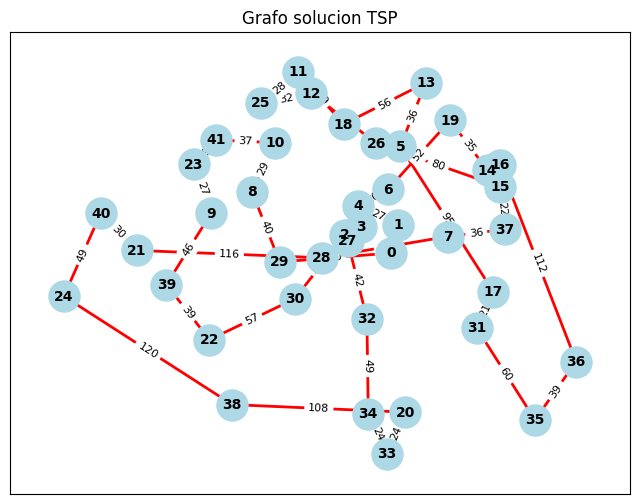

In [13]:
def recocido_simulado(problem, TEMPERATURA ):
  #problem = datos del problema
  #T = Temperatura

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo


  N=0
  while TEMPERATURA > .0001:
    N+=1
    #Genera una solución vecina
    vecina =genera_vecina_aleatorio(solucion_referencia)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina) ) :
      #solucion_referencia = copy.deepcopy(vecina)
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es " , end="")
  print(mejor_solucion)
  print("con una distancia total de " , end="")
  print(mejor_distancia)
  return mejor_solucion

sol  = recocido_simulado(problem, 10000000)

plot_tsp_solution(problem.edge_weights, sol)

# Actividades extra

**Mejora de algoritmo de búsqueda local**

*   Multiarranque
*   Busqueda en entornos variables

**Recocido simulado**

*   Mejora en la selección de vecinos



Arranque 1/5 -> distancia: 1565
Arranque 2/5 -> distancia: 1851
Arranque 3/5 -> distancia: 2019
Arranque 4/5 -> distancia: 1939
Arranque 5/5 -> distancia: 1781
Mejor solución (multiarranque): [0, 15, 16, 14, 19, 13, 12, 11, 25, 41, 23, 9, 29, 28, 2, 27, 3, 4, 6, 1, 7, 37, 17, 36, 35, 31, 20, 33, 34, 32, 30, 39, 21, 40, 24, 38, 22, 8, 10, 18, 26, 5]
Distancia                     : 1565


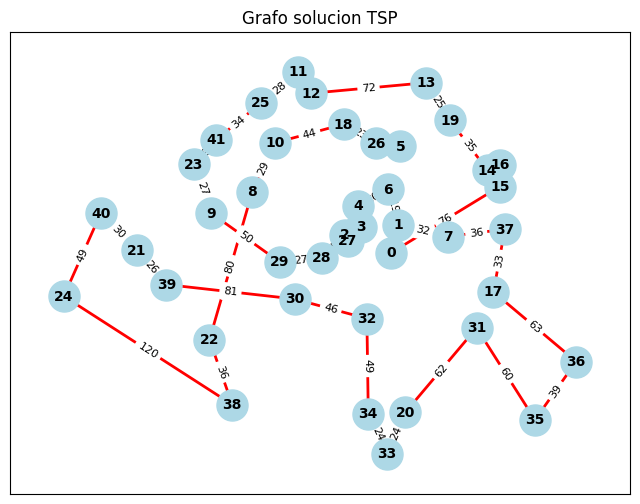

In [14]:
# BUSQUEDA LOCAL CON MULTIARRANQUE


def busqueda_local_multiarranque(problem, N_arranques):
  # N_arranques = número de veces que relanzamos la búsqueda local desde
  # una solución inicial distinta. Cada arranque converge a un óptimo local
  # (según el operador 2-opt) y nos quedamos con el mejor de todos ellos,
  # lo que reduce el riesgo de quedarnos atrapados en un óptimo local malo.

  mejor_solucion_global = []                      # Mejor solución encontrada entre todos los arranques
  mejor_distancia_global = float('inf')           # Su distancia asociada, inicializada a infinito

  for arranque in range(N_arranques):             # Repetimos el proceso N_arranques veces
    solucion_referencia = crear_solucion(Nodos)    # Generamos una solución inicial aleatoria distinta en cada arranque
    mejor_distancia_local = distancia_total(solucion_referencia, problem)  # Evaluamos esa solución inicial
    solucion_local = solucion_referencia           # La guardamos como mejor solución local de partida

    while True:                                    # Bucle de búsqueda local (idéntico al de busqueda_local)
      vecina = genera_vecina(solucion_local)        # Obtenemos la mejor vecina 2-opt de la solución actual
      distancia_vecina = distancia_total(vecina, problem)  # Evaluamos esa vecina

      if distancia_vecina < mejor_distancia_local:  # Si mejora, avanzamos hacia ella
        solucion_local = vecina
        mejor_distancia_local = distancia_vecina
      else:                                         # Si no mejora, hemos llegado a un óptimo local: paramos este arranque
        break

    print(f"Arranque {arranque+1}/{N_arranques} -> distancia: {mejor_distancia_local}")

    if mejor_distancia_local < mejor_distancia_global:  # Comparamos el óptimo local de este arranque con el mejor global
      mejor_distancia_global = mejor_distancia_local     # Si es mejor, actualizamos el óptimo global...
      mejor_solucion_global = solucion_local             # ...junto con la solución que lo produce

  print("Mejor solución (multiarranque):", mejor_solucion_global)
  print("Distancia                     :", mejor_distancia_global)
  return mejor_solucion_global


# Lanzamos 5 arranques independientes de búsqueda local
sol_multi = busqueda_local_multiarranque(problem, 5)

plot_tsp_solution(problem.edge_weights, sol_multi)

En la iteracion 73 , la mejor solución encontrada es: [0, 32, 30, 29, 10, 18, 26, 5, 7, 17, 31, 36, 35, 20, 33, 34, 38, 22, 24, 40, 21, 39, 28, 27, 4, 6, 14, 16, 15, 37, 1, 3, 2, 8, 9, 23, 41, 25, 11, 12, 13, 19]
Distancia     : 1663


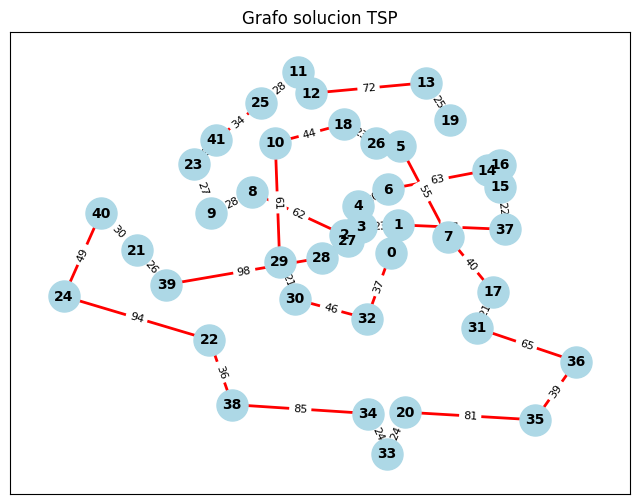

In [15]:
# BUSQUEDA EN ENTORNOS VARIABLES (VNS)

def genera_vecina_swap_adyacente(solucion):
  # Segundo operador de vecindad (más "pequeño" que 2-opt): intercambia
  # solo pares de nodos ADYACENTES en la ruta. Genera muchas menos vecinas
  # que 2-opt, por lo que sirve como entorno "más estrecho" dentro de VNS.
  mejor_solucion = []
  mejor_distancia = float('inf')
  for i in range(1, len(solucion)-1):             # Recorremos posiciones consecutivas
    vecina = solucion[:i] + [solucion[i+1], solucion[i]] + solucion[i+2:]  # Intercambiamos i con i+1
    distancia_vecina = distancia_total(vecina, problem)
    if distancia_vecina <= mejor_distancia:
      mejor_distancia = distancia_vecina
      mejor_solucion = vecina
  return mejor_solucion


def genera_vecina_insercion(solucion):
  # Tercer operador de vecindad: saca un nodo de su posición y lo inserta
  # en otra posición de la ruta (operador "or-opt" de tamaño 1). Es un
  # entorno distinto al de intercambio, útil para escapar de óptimos
  # locales que 2-opt y el swap adyacente no pueden mejorar.
  mejor_solucion = []
  mejor_distancia = float('inf')
  for i in range(1, len(solucion)):               # Nodo que sacamos de la ruta
    resto = solucion[:i] + solucion[i+1:]         # Ruta sin ese nodo
    nodo = solucion[i]
    for j in range(1, len(resto)+1):              # Probamos a insertarlo en cada posición posible
      vecina = resto[:j] + [nodo] + resto[j:]
      distancia_vecina = distancia_total(vecina, problem)
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


def busqueda_local_vns(problem):
  # VNS: en vez de usar un único operador de vecindad (2-opt), usamos una
  # LISTA de operadores. Empezamos por el primero; si no mejora, saltamos
  # al siguiente entorno (más grande/distinto); si alguno mejora, volvemos
  # siempre al primer entorno. Así exploramos entornos de distinta
  # "forma" antes de aceptar que estamos en un óptimo local.

  entornos = [genera_vecina, genera_vecina_swap_adyacente, genera_vecina_insercion]
  # Lista ordenada de operadores de vecindad a probar (k = índice del entorno actual)

  solucion_referencia = crear_solucion(Nodos)      # Solución inicial aleatoria
  mejor_distancia = distancia_total(solucion_referencia, problem)

  k = 0                                            # Empezamos por el primer entorno de la lista
  iteracion = 0

  while k < len(entornos):                         # Mientras queden entornos por probar
    iteracion += 1
    vecina = entornos[k](solucion_referencia)       # Generamos la mejor vecina con el entorno k
    distancia_vecina = distancia_total(vecina, problem)

    if distancia_vecina < mejor_distancia:          # Si el entorno k ha mejorado la solución...
      solucion_referencia = vecina                  # ...nos movemos a esa vecina...
      mejor_distancia = distancia_vecina
      k = 0                                         # ...y reiniciamos la búsqueda desde el primer entorno
    else:
      k += 1                                        # Si no mejora, probamos con el siguiente entorno (más "lejano")

  print("En la iteracion", iteracion, ", la mejor solución encontrada es:", solucion_referencia)
  print("Distancia     :", mejor_distancia)
  return solucion_referencia


sol_vns = busqueda_local_vns(problem)

plot_tsp_solution(problem.edge_weights, sol_vns)

La mejor solución encontrada es [0, 25, 10, 3, 4, 18, 11, 12, 27, 2, 8, 41, 23, 9, 39, 22, 38, 30, 28, 32, 34, 33, 20, 17, 37, 19, 13, 5, 26, 40, 24, 21, 29, 6, 14, 16, 15, 36, 35, 31, 7, 1]
con una distancia total de 1972


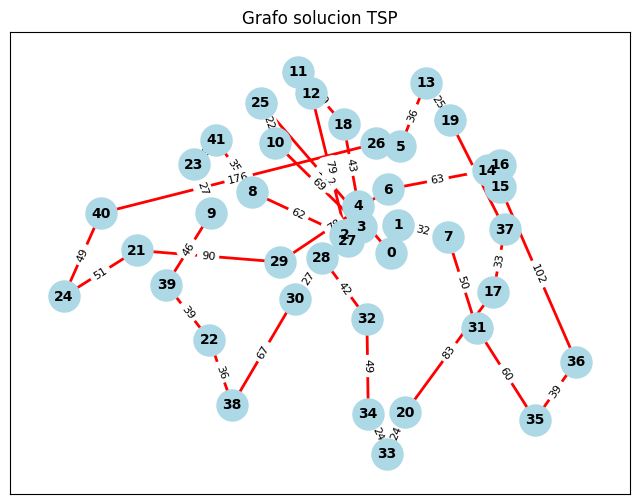

In [16]:
# RECOCIDO SIMULADO CON MEJORA EN LA SELECCION DE VECINOS


def genera_vecina_aleatorio_sesgada(solucion, problem, k_candidatos=5):
  # Mejora respecto a genera_vecina_aleatorio: en lugar de elegir los dos
  # nodos a intercambiar completamente al azar, elegimos el primero al
  # azar y el segundo lo sesgamos hacia nodos GEOGRÁFICAMENTE CERCANOS
  # al primero (usando la matriz de distancias del problema). Esto genera
  # vecinas de mejor calidad en promedio, porque intercambiar nodos muy
  # alejados casi siempre empeora la solución.

  i = random.randint(1, len(solucion)-1)          # Elegimos la primera posición al azar (nunca la 0, que es el nodo fijo de inicio)
  nodo_i = solucion[i]                             # Nodo que ocupa esa posición

  # Calculamos la distancia del nodo_i a todos los demás nodos de la ruta
  distancias = [(pos, distancia(nodo_i, solucion[pos], problem))
                for pos in range(1, len(solucion)) if pos != i]

  distancias.sort(key=lambda x: x[1])              # Ordenamos por distancia ascendente (más cercanos primero)
  candidatos = distancias[:k_candidatos]           # Nos quedamos con los k_candidatos nodos más cercanos a nodo_i

  j, _ = random.choice(candidatos)                 # Elegimos al azar UNO de esos vecinos cercanos (no el más lejano posible)

  i, j = sorted([i, j])                            # Ordenamos los índices para poder reconstruir la lista con slicing

  # Igual que genera_vecina_aleatorio: intercambiamos las posiciones i y j
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


def recocido_simulado_mejorado(problem, TEMPERATURA, k_candidatos=5):
  # Idéntico al recocido_simulado original, pero usando
  # genera_vecina_aleatorio_sesgada en lugar de genera_vecina_aleatorio.

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []
  mejor_distancia = float('inf')

  N = 0
  while TEMPERATURA > .0001:
    N += 1
    # Generamos la vecina con el nuevo generador sesgado hacia nodos cercanos
    vecina = genera_vecina_aleatorio_sesgada(solucion_referencia, problem, k_candidatos)
    distancia_vecina = distancia_total(vecina, problem)

    if distancia_vecina < mejor_distancia:          # Guardamos siempre la mejor solución vista hasta el momento
      mejor_solucion = vecina
      mejor_distancia = distancia_vecina

    # Igual que en el original: aceptamos si mejora, o con una probabilidad
    # que depende de T y de cuánto empeora, si no mejora
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina)):
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    TEMPERATURA = bajar_temperatura(TEMPERATURA)    # Reducimos la temperatura igual que en el original

  print("La mejor solución encontrada es ", end="")
  print(mejor_solucion)
  print("con una distancia total de ", end="")
  print(mejor_distancia)
  return mejor_solucion


sol_sa_mejorado = recocido_simulado_mejorado(problem, 10000000, k_candidatos=5)

plot_tsp_solution(problem.edge_weights, sol_sa_mejorado)